In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

import seqdata as sd
import seqpro as sp

from tangermeme.predict import predict

from cpgnet import CpGNet  # Replace with the correct path to your CpGNet implementation
from cpgnet.losses import BNLLLoss  # Replace with your BNLL loss function

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


In [2]:
path_sdata = "/cellar/users/aklie/projects/ML4GLand/tutorials/bulk_wgbs_basepair/eugene/prep_dataset/5kb/HepG2_WGBS.minimal.filtered.seqdata"

In [3]:
min_cov = 30
min_cpgs = 5
fold = "fold_0"

In [4]:
sdata = sd.open_zarr(path_sdata)
sdata

<xarray.Dataset> Size: 20GB
Dimensions:                     (_sequence: 433183, cov_sample: 2, _length: 5000)
Coordinates:
  * _sequence                   (_sequence) <U11 19MB 'loci_36' ... 'loci_611...
  * cov_sample                  (cov_sample) object 16B 'CpG_methylation_cove...
Dimensions without coordinates: _length
Data variables: (12/18)
    chrom                       (_sequence) object 3MB dask.array<chunksize=(61866,), meta=np.ndarray>
    chromEnd                    (_sequence) int64 3MB dask.array<chunksize=(61866,), meta=np.ndarray>
    chromStart                  (_sequence) int64 3MB dask.array<chunksize=(61866,), meta=np.ndarray>
    cov                         (_sequence, cov_sample, _length) float32 17GB dask.array<chunksize=(9538, 1, 5000), meta=np.ndarray>
    fold_0                      (_sequence) <U5 9MB dask.array<chunksize=(33347,), meta=np.ndarray>
    fold_1                      (_sequence) <U5 9MB dask.array<chunksize=(33347,), meta=np.ndarray>
    ...                          ...
    num_cpg_sites_covered       (_sequence) int64 3MB dask.array<chunksize=(54148,), meta=np.ndarray>
    seq                         (_sequence, _length) |S1 2GB dask.array<chunksize=(9538, 5000), meta=np.ndarray>
    strand                      (_sequence) object 3MB dask.array<chunksize=(61866,), meta=np.ndarray>
    total_cpg_coverage          (_sequence) float32 2MB dask.array<chunksize=(108296,), meta=np.ndarray>
    total_methylation_coverage  (_sequence) float32 2MB dask.array<chunksize=(108296,), meta=np.ndarray>
    type                        (_sequence) <U4 7MB dask.array<chunksize=(33347,), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [5]:
sdata['total_cov'] = (sdata.cov.sel(cov_sample='CpG_sites_coverage_rep1'))
sdata["methyl_cov"] = (sdata.cov.sel(cov_sample='CpG_methylation_coverage_rep1'))
sdata = sdata.drop_vars(['cov', 'cov_sample'])
sdata

<xarray.Dataset> Size: 20GB
Dimensions:                     (_sequence: 433183, _length: 5000)
Coordinates:
  * _sequence                   (_sequence) <U11 19MB 'loci_36' ... 'loci_611...
Dimensions without coordinates: _length
Data variables: (12/19)
    chrom                       (_sequence) object 3MB dask.array<chunksize=(61866,), meta=np.ndarray>
    chromEnd                    (_sequence) int64 3MB dask.array<chunksize=(61866,), meta=np.ndarray>
    chromStart                  (_sequence) int64 3MB dask.array<chunksize=(61866,), meta=np.ndarray>
    fold_0                      (_sequence) <U5 9MB dask.array<chunksize=(33347,), meta=np.ndarray>
    fold_1                      (_sequence) <U5 9MB dask.array<chunksize=(33347,), meta=np.ndarray>
    fold_2                      (_sequence) <U5 9MB dask.array<chunksize=(33347,), meta=np.ndarray>
    ...                          ...
    strand                      (_sequence) object 3MB dask.array<chunksize=(61866,), meta=np.ndarray>
    total_cpg_coverage          (_sequence) float32 2MB dask.array<chunksize=(108296,), meta=np.ndarray>
    total_methylation_coverage  (_sequence) float32 2MB dask.array<chunksize=(108296,), meta=np.ndarray>
    type                        (_sequence) <U4 7MB dask.array<chunksize=(33347,), meta=np.ndarray>
    total_cov                   (_sequence, _length) float32 9GB dask.array<chunksize=(9538, 5000), meta=np.ndarray>
    methyl_cov                  (_sequence, _length) float32 9GB dask.array<chunksize=(9538, 5000), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [6]:
training_idx = np.where(sdata[fold].isin(["train", "valid"]))[0]
training_data = sdata.isel(_sequence=training_idx)
training_data

<xarray.Dataset> Size: 15GB
Dimensions:                     (_sequence: 340204, _length: 5000)
Coordinates:
  * _sequence                   (_sequence) <U11 15MB 'loci_49794' ... 'loci_...
Dimensions without coordinates: _length
Data variables: (12/19)
    chrom                       (_sequence) object 3MB dask.array<chunksize=(28783,), meta=np.ndarray>
    chromEnd                    (_sequence) int64 3MB dask.array<chunksize=(28783,), meta=np.ndarray>
    chromStart                  (_sequence) int64 3MB dask.array<chunksize=(28783,), meta=np.ndarray>
    fold_0                      (_sequence) <U5 7MB dask.array<chunksize=(264,), meta=np.ndarray>
    fold_1                      (_sequence) <U5 7MB dask.array<chunksize=(264,), meta=np.ndarray>
    fold_2                      (_sequence) <U5 7MB dask.array<chunksize=(264,), meta=np.ndarray>
    ...                          ...
    strand                      (_sequence) object 3MB dask.array<chunksize=(28783,), meta=np.ndarray>
    total_cpg_coverage          (_sequence) float32 1MB dask.array<chunksize=(44840,), meta=np.ndarray>
    total_methylation_coverage  (_sequence) float32 1MB dask.array<chunksize=(44840,), meta=np.ndarray>
    type                        (_sequence) <U4 5MB dask.array<chunksize=(264,), meta=np.ndarray>
    total_cov                   (_sequence, _length) float32 7GB dask.array<chunksize=(5069, 5000), meta=np.ndarray>
    methyl_cov                  (_sequence, _length) float32 7GB dask.array<chunksize=(5069, 5000), meta=np.ndarray>
Attributes:
    length_dim:    _length
    max_jitter:    0
    sequence_dim:  _sequence

In [7]:
def transform(batch):
    batch["seq"] = sp.DNA.ohe(batch["seq"]).transpose(0, 2, 1)
    return batch

In [8]:
train_idx = np.where(training_data[fold] == "train")[0]
train_data = training_data.isel(_sequence=train_idx).load()
train_dl = sd.get_torch_dataloader(
    train_data,
    sample_dims=['_sequence'],
    variables=["seq", "methyl_cov", "total_cov"],
    prefetch_factor=None,
    transform=transform,
    batch_size=128,
    shuffle=True,
    return_tuples=True
)
print(f"Dataloader contains {len(train_dl)} batches")
batch = next(iter(train_dl))

Dataloader contains 2393 batches


In [9]:
batch[0].shape, batch[1].shape, batch[2].shape

(torch.Size([128, 4, 5000]), torch.Size([128, 5000]), torch.Size([128, 5000]))

In [10]:
# Extract data
valid_idx = np.where(training_data[fold] == "valid")[0]
valid_data = training_data.isel(_sequence=valid_idx)
X_valid = torch.tensor(sp.ohe(valid_data.seq.values, alphabet=sp.DNA), dtype=torch.float32).permute(0, 2, 1)  # One-hot encoded sequences
y_methyl_valid = torch.tensor(valid_data["methyl_cov"].values, dtype=torch.float32)  # Methylated coverage
y_cov_valid = torch.tensor(valid_data["total_cov"].values, dtype=torch.float32)  # Total coverage

# Print data summary
print("Sequences (shape):", X_valid.shape)
print("Total coverage (shape):", y_cov_valid.shape)
print("Methylated coverage (shape):", y_methyl_valid.shape)

Sequences (shape): torch.Size([34018, 4, 5000])
Total coverage (shape): torch.Size([34018, 5000])
Methylated coverage (shape): torch.Size([34018, 5000])


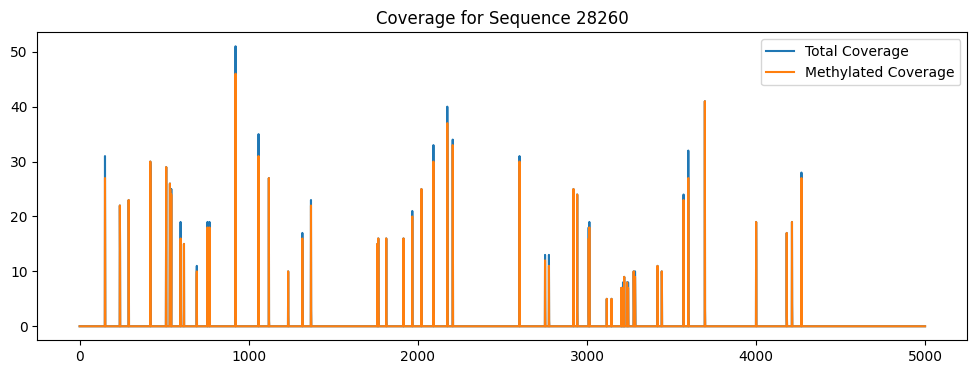

In [11]:
random_idx = torch.randint(0, X_valid.shape[0], (1,)).item()
plt.figure(figsize=(12, 4))
plt.plot(y_cov_valid[random_idx].numpy(), label="Total Coverage")
plt.plot(y_methyl_valid[random_idx].numpy(), label="Methylated Coverage")
plt.legend()
plt.title(f"Coverage for Sequence {random_idx}")
plt.show()

# Model

In [12]:
# 2. Initialize Random Model
model = CpGNet(
    n_filters=64, 
    n_layers=4, 
    min_cov=3, 
    verbose=True, 
    trimming=0,
    name="/cellar/users/aklie/projects/ML4GLand/tutorials/bulk_wgbs_basepair/eugene/fit/fold_0/5kb/HepG2_WGBS"
)
model.eval()  # Set to evaluation mode for testing

CpGNet(
  (iconv): Conv1d(4, 64, kernel_size=(21,), stride=(1,), padding=(10,))
  (irelu): ReLU()
  (rconvs): ModuleList(
    (0): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,), dilation=(2,))
    (1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(4,))
    (2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(8,), dilation=(8,))
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(16,), dilation=(16,))
  )
  (rrelus): ModuleList(
    (0-3): 4 x ReLU()
  )
  (fconv): Conv1d(64, 2, kernel_size=(75,), stride=(1,), padding=(37,))
)

In [13]:
predict?

Signature: predict(model, X, args=None, batch_size=32, device='cuda', verbose=False)
Docstring:
Make batched predictions in a memory-efficient manner.

This function will take a PyTorch model and make predictions from it using
the forward function, with optional additional arguments to the model. The
additional arguments must have the same batch size as the examples, and the
i-th example will be given to the model with the i-th index of each
additional argument. 

Before starting predictions, the model is moved to the specified device. As 
predictions are being made, each batch is also moved to the specified 
device and then moved back to the CPU after predictions are made. This is
to allow the function to work on massive numbers of examples that would
not necessarily each fit in memory. If the batches themselves do not fit
in memory, try lowering the batch size.


Parameters
----------
model: torch.nn.Module
        The PyTorch model to use to make predictions.

X: torch.tensor, shape

In [14]:
# Compute methylation fractions (ensure no division by zero)
y_frac = y_methyl_valid / (y_cov_valid + 1e-8)

# 3. Forward Pass with Randomly Initialized Model
with torch.no_grad():  # No need for gradients during this test
    y_pred = predict(model, X_valid, verbose=True)

# Extract predicted alpha and beta logits
y_alpha = torch.nn.functional.softplus(y_pred[:, 0, :])  # Predicted alpha parameters
y_beta = torch.nn.functional.softplus(y_pred[:, 1, :])  # Predicted beta parameters

print("Predicted Alpha (shape):", y_alpha.shape)
print("Predicted Beta (shape):", y_beta.shape)

Predicted Alpha (shape): torch.Size([34018, 5000])
Predicted Beta (shape): torch.Size([34018, 5000])


In [15]:
learning_rate = 1e-3
max_epochs = 100

In [16]:
# Move the model to the GPU and prepare the optimizer
model.cuda()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(f"Optimizer: {optimizer}")

Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [22]:
%load_ext autoreload
%autoreload 2

In [53]:
# Use the models fit_generator method to train the model
print("Fitting the model")
model.fit(
    train_dl,
    optimizer,
    X_valid=X_valid,
    y_cov_valid=y_cov_valid,
    y_methyl_valid=y_methyl_valid,
    max_epochs=max_epochs,
    validation_iter=100,
)

Fitting the model
Epoch	Iteration	Training Time	Validation Time	Training BNLL	Validation BNLL	Validation Pearson	Saved?
0	0	3.2405	5.3816	-2.6541	-7.0127	0.0052	True
0	100	10.4523	4.553	-7.0635	-7.0655	0.1499	True
0	200	9.6831	4.531	-6.9773	-7.0804	0.2038	True
0	300	9.6057	4.5057	-6.7364	-7.0786	0.2441	False
0	400	9.5549	4.5303	-7.1016	-7.0787	0.2642	False
0	500	9.5937	4.5646	-6.7963	-7.0913	0.28	True
0	600	9.6361	4.5419	-7.1461	-7.0978	0.2917	True
0	700	9.6028	4.5398	-7.1203	-7.088	0.301	False
0	800	9.6075	4.5235	-6.9987	-7.0816	0.3191	False
0	900	9.5956	4.5476	-7.2151	-7.1037	0.3311	True
0	1000	9.6549	4.5336	-6.9434	-7.11	0.3273	True
0	1100	9.6565	4.5593	-7.4347	-7.1076	0.3384	False
0	1200	9.6491	4.5667	-6.8317	-7.0959	0.3438	False
0	1300	9.6501	4.545	-7.2924	-7.1129	0.351	True
0	1400	9.645	4.5262	-7.1624	-7.1116	0.3521	False
0	1500	9.6194	4.5753	-7.178	-7.1054	0.354	False
0	1600	9.6827	4.5431	-7.2962	-7.1185	0.3672	True
0	1700	9.645	4.5334	-6.9804	-7.0945	0.3664	False
0	1800	9.6443	

# Testing

In [17]:
# 4. Calculate BNLL Loss
# In this example, we assume CpG sites will be dynamically detected
cpg_mask = model.detect_cpg_sites(X_valid)  # Shape: (B, L)
coverage_mask = (y_cov_valid >= model.min_cov).float()
final_mask = cpg_mask * coverage_mask
final_mask

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [18]:
np.where(cpg_mask[0])[0]

array([   5,    6,  135,  136,  209,  210,  488,  489,  657,  658,  721,
        722,  730,  731,  798,  799,  835,  836, 1380, 1381, 1439, 1440,
       1491, 1492, 1641, 1642, 1815, 1816, 2174, 2175, 2349, 2350, 2821,
       2822, 3065, 3066, 3077, 3078, 3222, 3223, 3424, 3425, 3452, 3453,
       3489, 3490, 3627, 3628, 3677, 3678, 3726, 3727, 3905, 3906, 4137,
       4138, 4166, 4167, 4260, 4261, 4311, 4312, 4339, 4340, 4401, 4402,
       4407, 4408, 4682, 4683, 4937, 4938])

In [19]:
np.where(final_mask[0])[0]

array([   6,  135,  136,  209,  488,  489,  657,  658,  721,  722,  730,
        731,  798,  835,  836, 1380, 1381, 1439, 1440, 1491, 1641, 1642,
       1815, 2174, 2349, 2350, 2821, 2822, 3065, 3066, 3077, 3078, 3222,
       3223, 3424, 3452, 3453, 3490, 3628, 3677, 3678, 3726, 3727, 3906,
       4137, 4138, 4166, 4167, 4260, 4261, 4312, 4340, 4402, 4408, 4682,
       4683, 4937])

In [20]:
np.where(y_cov_valid[0] > 0.0)[0]

array([   5,    6,  135,  136,  209,  210,  488,  489,  657,  658,  721,
        722,  730,  731,  798,  799,  835,  836, 1380, 1381, 1439, 1440,
       1491, 1492, 1641, 1642, 1815, 1816, 2174, 2349, 2350, 2821, 2822,
       3065, 3066, 3077, 3078, 3222, 3223, 3424, 3425, 3452, 3453, 3489,
       3490, 3627, 3628, 3677, 3678, 3726, 3727, 3906, 4137, 4138, 4166,
       4167, 4260, 4261, 4311, 4312, 4340, 4402, 4408, 4682, 4683, 4937,
       4938])

In [22]:
valid_data["seq"][0].values[5:7]

array([b'C', b'G'], dtype='|S1')

In [45]:
y_alpha

tensor([[0.5855, 0.5517, 0.5700,  ..., 0.7650, 0.7216, 0.7582],
        [0.6191, 0.6412, 0.6047,  ..., 0.8122, 0.8190, 0.8355],
        [0.6340, 0.5824, 0.5730,  ..., 0.7710, 0.7617, 0.8273],
        ...,
        [0.6001, 0.5873, 0.6532,  ..., 0.8066, 0.8100, 0.7766],
        [0.6244, 0.5983, 0.5554,  ..., 0.7237, 0.7401, 0.7327],
        [0.6028, 0.6898, 0.6365,  ..., 0.7757, 0.7399, 0.7659]])

In [46]:
y_beta

tensor([[0.8702, 0.8679, 0.8632,  ..., 0.7169, 0.6396, 0.7421],
        [0.7624, 0.7342, 0.8794,  ..., 0.7870, 0.7292, 0.7352],
        [0.6962, 0.7452, 0.7006,  ..., 0.6502, 0.7389, 0.6400],
        ...,
        [0.7820, 0.7476, 0.7279,  ..., 0.5888, 0.7365, 0.7501],
        [0.7803, 0.7553, 0.7005,  ..., 0.7082, 0.7114, 0.7283],
        [0.8605, 0.7692, 0.7809,  ..., 0.7965, 0.7876, 0.7915]])

In [49]:
final_mask.shape

torch.Size([34018, 5000])

In [52]:
y_frac[final_mask == 1]

tensor([0.8125, 1.0000, 1.0000,  ..., 0.6250, 0.6667, 0.4000])

In [23]:
loss = BNLLLoss(y_alpha, y_beta, y_frac, mask=final_mask)
print(f"BNLL Loss: {loss.item():.4f}")

BNLL Loss: -2.6769


In [28]:
from cpgnet.performance import calculate_performance_measures

ImportError: cannot import name 'smooth_pearson_corr' from 'cpgnet.performance' (/cellar/users/aklie/projects/ML4GLand/cpgnet/cpgnet/performance.py)

In [32]:
import torch

def pearson_corr(arr1, arr2):
    """Pearson correlation, ignoring NaNs."""
    mean1 = torch.nanmean(arr1, dim=-1, keepdim=True)
    mean2 = torch.nanmean(arr2, dim=-1, keepdim=True)
    dev1, dev2 = arr1 - mean1, arr2 - mean2

    numer = torch.nansum(dev1 * dev2, dim=-1)  # Covariance
    denom = torch.sqrt(torch.nansum(dev1 ** 2, dim=-1) * torch.nansum(dev2 ** 2, dim=-1))  # Variances

    corr = numer / denom
    corr[torch.isnan(corr) | (denom == 0)] = float('nan')  # Handle invalid cases
    return corr


def calculate_performance_measures(
    alphas,
    betas,
    fracs,
    mask,
    measures=None,
    batch_size=200
):
    """
    Calculate performance measures for CpG site predictions in batches.

    Parameters
    ----------
    alphas : torch.Tensor
        Predicted alpha parameters for the Beta distribution, shape (B, L).
    betas : torch.Tensor
        Predicted beta parameters for the Beta distribution, shape (B, L).
    fracs : torch.Tensor
        True methylation fractions, shape (B, L).
    mask : torch.Tensor
        Binary mask indicating valid CpG sites, shape (B, L).
    measures : list of str, optional
        List of measures to calculate. Options include:
        - 'bnll': Beta Negative Log-Likelihood loss.
        - 'jsd': Jensen-Shannon Distance.
        - 'pearson': Pearson correlation.
        - 'spearman': Spearman correlation.
        - 'mse': Mean Squared Error.
        If None, all measures will be calculated.
    batch_size : int, optional
        The number of sequences to process in each batch (default: 200).

    Returns
    -------
    dict
        Dictionary of calculated measures, where each value is a tensor of shape (B,).
    """
    measures_ = {m: torch.full((alphas.shape[0],), float('nan'), device=alphas.device) for m in measures or ['bnll', 'jsd', 'pearson', 'spearman', 'mse']}

    n = alphas.shape[0]
    for start in range(0, n, batch_size):
        end = start + batch_size

        # Slice the batch
        batch_alphas = alphas[start:end]
        batch_betas = betas[start:end]
        batch_fracs = fracs[start:end]
        batch_mask = mask[start:end]

        # Calculate predictions
        batch_preds = batch_alphas / (batch_alphas + batch_betas + 1e-8)

        # Replace invalid positions with NaN
        nan_value = torch.tensor(float('nan'), device=batch_fracs.device)
        nan_batch_fracs = torch.where(batch_mask.bool(), batch_fracs, nan_value.expand_as(batch_fracs))
        nan_batch_preds = torch.where(batch_mask.bool(), batch_preds, nan_value.expand_as(batch_preds))

        # Iterate over measures
        for measure in measures_:
            if measure == 'bnll':
                bnll = BNLLLoss(batch_alphas, batch_betas, batch_fracs, mask=batch_mask)
                measures_['bnll'][start:end] = bnll
            elif measure == 'jsd':
                jsd = jensen_shannon_distance(nan_batch_fracs, nan_batch_preds)
                measures_['jsd'][start:end] = jsd
            elif measure == 'pearson':
                pearson = pearson_corr(nan_batch_fracs, nan_batch_preds)
                measures_['pearson'][start:end] = pearson
            elif measure == 'spearman':
                spearman = spearman_corr(nan_batch_fracs, nan_batch_preds)
                measures_['spearman'][start:end] = spearman
            elif measure == 'mse':
                mse = mean_squared_error(nan_batch_fracs, nan_batch_preds)
                measures_['mse'][start:end] = mse

    return measures_

In [33]:
nan_value = torch.tensor(float('nan'), device=y_frac.device)
nan_value

tensor(nan)

In [34]:
y_frac.shape, final_mask.shape

(torch.Size([34018, 5000]), torch.Size([34018, 5000]))

In [35]:
# 3. Calculate Performance Metrics
# Define the performance measures to calculate
measures = ['pearson']

# Calculate performance metrics
metrics = calculate_performance_measures(
    alphas=y_alpha,
    betas=y_beta,
    fracs=y_frac,
    mask=final_mask,
    measures=measures,
    batch_size=200
)

metrics

{'pearson': tensor([ 0.0691,  0.0710, -0.0358,  ...,  0.0569,  0.1984, -0.0441])}

In [36]:
# 4. Print Metrics
print("Performance Metrics:")
for measure, value in metrics.items():
    print(f"{measure.upper()}: {np.nanmean(value.cpu().numpy()):.4f}")

Performance Metrics:
PEARSON: 0.0049


In [37]:
preds = y_alpha / (y_alpha + y_beta + 1e-8)

In [38]:
nan_value = torch.tensor(float('nan'), device=y_frac.device)
nan_y_frac = torch.where(final_mask.bool(), y_frac, nan_value.expand_as(y_frac))
nan_preds = torch.where(final_mask.bool(), preds, nan_value.expand_as(preds))

In [39]:
nan_y_frac

tensor([[   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan, 0.9167,  ...,    nan,    nan,    nan],
        ...,
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan]])

In [40]:
nan_preds

tensor([[   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan, 0.4499,  ...,    nan,    nan,    nan],
        ...,
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan],
        [   nan,    nan,    nan,  ...,    nan,    nan,    nan]])

In [41]:
pearson_corr(nan_y_frac, nan_preds)

tensor([ 0.0691,  0.0710, -0.0358,  ...,  0.0569,  0.1984, -0.0441])

In [42]:
y_frac[0]

tensor([0., 0., 0.,  ..., 0., 0., 0.])

In [43]:
preds

tensor([[0.4022, 0.3886, 0.3977,  ..., 0.5162, 0.5301, 0.5054],
        [0.4481, 0.4662, 0.4074,  ..., 0.5079, 0.5290, 0.5319],
        [0.4766, 0.4387, 0.4499,  ..., 0.5425, 0.5076, 0.5638],
        ...,
        [0.4342, 0.4400, 0.4730,  ..., 0.5781, 0.5238, 0.5087],
        [0.4445, 0.4420, 0.4422,  ..., 0.5054, 0.5099, 0.5015],
        [0.4120, 0.4728, 0.4490,  ..., 0.4934, 0.4844, 0.4918]])

In [44]:
metrics

{'pearson': tensor([ 0.0691,  0.0710, -0.0358,  ...,  0.0569,  0.1984, -0.0441])}